In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# CSVファイルの読み込み
log2fc_data = pd.read_csv('log2FC_CperHC.csv')  # log2 fold changeのデータ
log10fdr_data = pd.read_csv('log10_q_pvalues_CvsHC.csv')  # -log10 FDRのデータ

# データが同じインデックス順に並んでいると仮定し、2つのデータフレームを連結
# 必要に応じて 'ID' や 'Gene' などの共通カラムで結合してください
data = pd.concat([log2fc_data, log10fdr_data], axis=1)
data = data.drop("protein",axis = 1)

data.columns = ['proteins','log2FC', 'log10FDR']

data.head()

,proteins,log2FC,log10FDR
0,CRYBB2,0.019526,0.034811
1,RAF1,-0.054850,0.038368
2,ZNF41,-0.448844,0.038368
3,ELK1,0.360236,0.038364
4,GUCA1A,-0.033673,0.023191


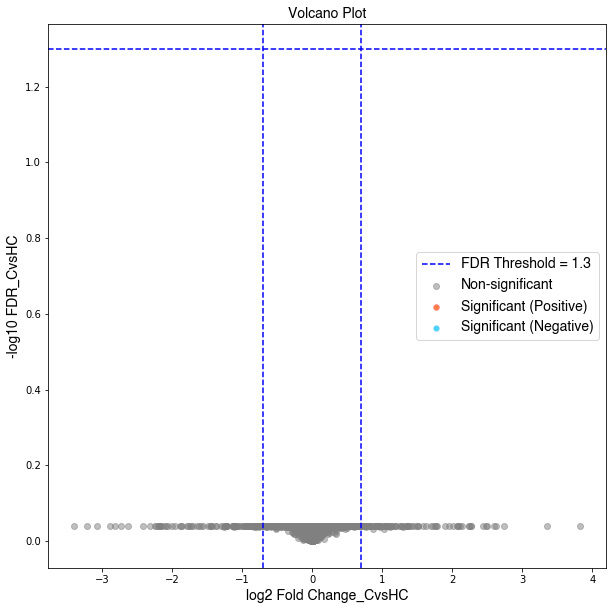

In [33]:
name = "CvsHC"

# 閾値の設定（例としてlog2FC > 1または< -1、log10FDR > 1.3を有意値と仮定）
fc_threshold = 0.7
fdr_threshold = 1.3

# ボルケーノプロットの作成
plt.figure(figsize=(10, 10))

# グレーの点（有意ではないデータポイント）
non_significant = ~(abs(data['log2FC']) > fc_threshold) | (data['log10FDR'] <= fdr_threshold)
plt.scatter(data.loc[non_significant, 'log2FC'], data.loc[non_significant, 'log10FDR'],
            color='gray', alpha=0.5, label='Non-significant')

# プラス側の有意なデータポイント（オレンジ色、薄い枠あり）
significant_pos = (data['log2FC'] > fc_threshold) & (data['log10FDR'] > fdr_threshold)
plt.scatter(data.loc[significant_pos, 'log2FC'], data.loc[significant_pos, 'log10FDR'],
            color='#ff4500', edgecolor='lightcoral', linewidth=0.5, alpha=0.7, label='Significant (Positive)')

# マイナス側の有意なデータポイント（水色、薄い枠あり）
significant_neg = (data['log2FC'] < -fc_threshold) & (data['log10FDR'] > fdr_threshold)
plt.scatter(data.loc[significant_neg, 'log2FC'], data.loc[significant_neg, 'log10FDR'],
            color='#00bfff', edgecolor='lightblue', linewidth=0.5, alpha=0.7, label='Significant (Negative)')

# プロットの調整
plt.axhline(y=fdr_threshold, color='blue', linestyle='--', label=f'FDR Threshold = {fdr_threshold}')
plt.axvline(x=fc_threshold, color='blue', linestyle='--')
plt.axvline(x=-fc_threshold, color='blue', linestyle='--')

#軸ラベルに、何と何の比較なのか示す名前

# ラベルとタイトル、フォント設定
plt.xlabel('log2 Fold Change_' + name, fontsize=14, family='Helvetica')
plt.ylabel('-log10 FDR_' + name, fontsize=14, family='Helvetica')
plt.title('Volcano Plot', fontsize=14, family='Helvetica')
plt.legend(prop={'size': 14, 'family': 'Helvetica'})

# プロットの表示
plt.show()
